In [1]:
import json
import os
import time
import warnings

import gc

import h5py
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np
import pandas as pd
import pysam
import pyfaidx
import pybedtools
import csv
import tensorflow as tf

from baskerville import seqnn
from baskerville import gene as bgene
from baskerville import dna

from borzoi_helpers_covr import *

tf.compat.v1.logging.set_verbosity(tf.compat.v1.logging.ERROR)
#os.environ['CUDA_VISIBLE_DEVICES'] = '-1'

2025-10-06 08:56:11.283125: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-10-06 08:56:11.283181: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-10-06 08:56:11.284231: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-10-06 08:56:11.290795: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-10-06 08:56:12.687701: W tensorflow/comp

In [ ]:
#Model configuration

params_file = 'params_pred.json'
targets_file = 'targets_rna3_only.txt' #Subset of targets.txt

seq_len = 524288
n_reps = 4       #To use only one model replicate, set to 'n_reps = 1'. To use all four replicates, set 'n_reps = 4'.
rc = True         #Average across reverse-complement prediction

#Read model parameters

with open(params_file) as params_open :
    
    params = json.load(params_open)
    
    params_model = params['model']
    params_train = params['train']

#Remove cropping
params_model['trunk'][-1]['cropping'] = 0

#Read targets

targets_df = pd.read_csv(targets_file, index_col=0, sep='\t')
target_index = targets_df.index

#Create local index of strand_pair (relative to sliced targets)
if rc :
    strand_pair = targets_df.strand_pair
    
    target_slice_dict = {ix : i for i, ix in enumerate(target_index.values.tolist())}
    slice_pair = np.array([
        target_slice_dict[ix] if ix in target_slice_dict else ix for ix in strand_pair.values.tolist()
    ], dtype='int32')

#Initialize model ensemble

models = []
for rep_ix in range(n_reps) :
    
    model_file = "saved_models/f3c" + str(rep_ix) + "/train/model0_best.h5"

    seqnn_model = seqnn.SeqNN(params_model)
    seqnn_model.restore(model_file, 0)
    seqnn_model.build_slice(target_index)
    if rc :
        seqnn_model.strand_pair.append(slice_pair)
    seqnn_model.build_ensemble(rc, [0])
    
    models.append(seqnn_model)


In [5]:
#Load genome fasta and gene annotations

#Initialize fasta sequence extractor
fasta_open = pysam.Fastafile('hg38/assembly/ucsc/hg38.fa')

#Load gene/exon annotation
gtf_file = 'hg38/genes/gencode41/gencode41_basic_nort_protein.gtf'

transcriptome = bgene.Transcriptome(gtf_file)

#Get gene span bedtool
bedt_span = transcriptome.bedtool_span()

#Load APA atlas
apa_df = pd.read_csv('/home/jlinder/seqnn/data/apa/polyadb_human_v3_utr3_filtered_max_var.csv.gz', sep='\t', compression='gzip')
apa_df = apa_df[['pas_id', 'gene', 'chrom', 'position_hg38', 'strand', 'site_num', 'num_sites', 'site_num_kept', 'site_type', 'pas_type', 'total_count', 'gtex_blood_pred']]

apa_df = apa_df.loc[(~apa_df['gtex_blood_pred'].isnull())].copy().reset_index(drop=True)
apa_df = apa_df.sort_values(by=['chrom', 'gene', 'site_num_kept'], ascending=True).copy().reset_index(drop=True)

apa_df.loc[apa_df['pas_type'] == 'NoPAS', 'pas_type'] = 'No_CSE'

#Only consider 3' UTR sites
apa_df_utr = apa_df.query("site_type == '3\\' most exon'").copy().reset_index(drop=True)

#Or intronic sites
apa_df_intron = apa_df.query("site_type == 'Intron' and pas_type != 'No_CSE'").copy().reset_index(drop=True)

print("len(apa_df_utr) = " + str(len(apa_df_utr)))
print("len(apa_df_intron) = " + str(len(apa_df_intron)))

#Load TSS atlas
tss_df = pd.read_csv('hg38/genes/gencode41/gencode41_basic_tss2.bed', sep='\t', names=['chrom', 'position_hg38', 'end', 'tss_id', 'feat1', 'strand'])
tss_df['gene'] = tss_df['tss_id'].apply(lambda x: x.split("/")[1] if "/" in x else x)

print("len(tss_df) = " + str(len(tss_df)))


len(apa_df_utr) = 42428
len(apa_df_intron) = 0
len(tss_df) = 116649


In [6]:
#Get stranded targets

def targets_prep_strand(targets_df) :
    
    #Attach strand
    targets_strand = []
    for _, target in targets_df.iterrows() :
        if target.strand_pair == target.name :
            targets_strand.append('.')
        else :
            targets_strand.append(target.identifier[-1])
    targets_df['strand'] = targets_strand

    #Collapse stranded
    strand_mask = (targets_df.strand != '-')
    targets_strand_df = targets_df[strand_mask]

    return targets_strand_df

targets_strand_df = targets_prep_strand(targets_df)


In [7]:
#Load ISM gene dataframe

ism_genes_csv_file = '/home/jlinder/seqnn/data/apa/polyadb_human_v3_utr3_filtered2_max_var_gene_brain_short_6.csv.gz'
ism_gene_df = pd.read_csv(ism_genes_csv_file, compression='gzip', sep='\t')

print("len(ism_gene_df) = " + str(len(ism_gene_df)))


len(ism_gene_df) = 6


In [8]:
#Print ISM dataframe
ism_gene_df


,Unnamed: 0,gene,chrom,strand,num_sites,end_hg38,stop_hg38,position_hg38,gtex_brain_total_pred,gtex_brain_mean_pred,...,brain_log2fc2_true,not_brain_qtl_pred,not_brain_qtl_true,brain_qtl_pred,brain_qtl_true,brain_log2fc_avg,brain_rank,brain_log2fc2_avg,brain_rank2,sort_order
0,0,ARPC5L,chr9,+,4,124877733,124876940,124877657,4456.976952,1114.244238,...,2.297100,0.935448,0.894964,0.852254,0.867557,1.133122,590,1.718765,309,1000000.0
1,1,ISCA1,chr9,-,4,86264476,86266045,86264546,3099.768267,774.942067,...,2.033155,0.808431,0.737062,0.799110,0.707429,1.285099,444,1.977397,183,1000000.0
2,2,MDH2,chr7,+,4,76067508,76066410,76067462,7897.433059,1974.358265,...,3.289826,0.985531,0.971480,0.959794,0.906789,2.666918,28,2.830972,28,1000000.0
3,3,OSER1,chr20,-,4,44195939,44197054,44195939,2553.520410,638.380102,...,2.745017,0.907067,0.902476,0.685309,0.553840,1.823722,146,2.356233,86,1000000.0
4,4,RAE1,chr20,+,2,57379211,57378099,57379202,741.279055,370.639527,...,4.351027,0.570256,0.594046,0.457568,0.472176,3.472967,7,3.472940,10,1000000.0
5,5,SLC20A2,chr8,-,4,42416475,42417805,42416475,2090.121091,522.530273,...,1.781032,0.567752,0.384252,0.517947,0.737062,1.242596,486,1.434043,498,1000000.0


In [9]:
#Load gene example

search_gene = 'ENSG00000146701'
ism_gene_ix = 2

ism_gene_row = ism_gene_df.iloc[ism_gene_ix]

#Load ISM scores
ism_file = h5py.File('/home/jlinder/analysis/bench_apa_v4/apa_ism_human_6_rna3_short/ism_f0c0.h5', 'r')

chrom = ism_file['chr'][ism_gene_ix].decode()
start = int(ism_file['start'][ism_gene_ix])
end = int(ism_file['end'][ism_gene_ix])

ism_file.close()


In [10]:
#Get sequence for target gene

pas_ext = 100

model_subset = None

load_isoforms = True

utr_len = int(abs(ism_gene_row['end_hg38'] - ism_gene_row['stop_hg38']))

if ism_gene_row['strand'] == '+' :
    utr_start = ism_gene_row['stop_hg38'] - pas_ext - int(0.5 * utr_len)
    utr_end = ism_gene_row['end_hg38'] + 1 + pas_ext
else :
    utr_start = ism_gene_row['end_hg38'] - pas_ext
    utr_end = ism_gene_row['stop_hg38'] + 1 + pas_ext + int(0.5 * utr_len)

#Get exon bin range
gene_keys = [gene_key for gene_key in transcriptome.genes.keys() if search_gene in gene_key]

gene = transcriptome.genes[gene_keys[0]]
gene_strand = gene.strand

g_start, g_end = gene.span()
gene_width = (g_end - g_start)

#Calculate optimal plot width
plot_width = 0
if gene_width * 1.25 <= 4096 :
    plot_width = 4096
elif gene_width * 1.25 <= 8192 :
    plot_width = 8192
elif gene_width * 1.25 <= 16384 :
    plot_width = 16384
elif gene_width * 1.25 <= 2*16384 :
    plot_width = 2*16384
elif gene_width * 1.25 <= 4*16384 :
    plot_width = 4*16384
elif gene_width * 1.25 <= 6*16384 :
    plot_width = 6*16384
elif gene_width * 1.25 <= 8*16384 :
    plot_width = 8*16384
elif gene_width * 1.25 <= 12*16384 :
    plot_width = 12*16384
else :
    plot_width = 524288

if chrom is None or start is None or end is None :
    chrom = gene.chrom
    mid = (g_start + g_end) // 2
    start = mid - 524288 // 2
    end = mid + 524288 // 2

#Determine output sequence start
seq_out_start = start + seqnn_model.model_strides[0]*seqnn_model.target_crops[0]
seq_out_len = seqnn_model.model_strides[0]*seqnn_model.target_lengths[0]

#Determine output positions of gene exons
gene_slice = gene.output_slice(seq_out_start, seq_out_len, seqnn_model.model_strides[0], False, old_version=True)

#Get sequence bedtool
seq_bedt = pybedtools.BedTool('%s %d %d' % (chrom, start, end), from_string=True)

#Get all genes (exons and strands) overlapping input window
gene_ids = sorted(list(set([overlap[3] for overlap in bedt_span.intersect(seq_bedt, wo=True) if search_gene not in overlap[3]])))
gene_slices = []
gene_strands = []
for gene_id in gene_ids :
    gene_slices.append(transcriptome.genes[gene_id].output_slice(seq_out_start, seq_out_len, seqnn_model.model_strides[0], False, old_version=True))
    gene_strands.append(transcriptome.genes[gene_id].strand)

#Get 3' UTR pA sites for gene
apa_df_gene_utr = apa_df_utr.query("gene == '" + gene.name + "'").copy().reset_index(drop=True)[['chrom', 'gene', 'strand', 'position_hg38']]
apa_df_gene_intron = apa_df_intron.query("gene == '" + gene.name + "'").copy().reset_index(drop=True)[['chrom', 'gene', 'strand', 'position_hg38']]

prox_pos = apa_df_gene_utr.iloc[0]['position_hg38']
dist_pos = ism_gene_row['position_hg38']

#Get TSS sites for gene
tss_df_gene = tss_df.loc[tss_df['gene'].str.contains(search_gene)].copy().reset_index(drop=True)[['chrom', 'gene', 'strand', 'position_hg38']]

def _switch_transcript_id(id_str) :
    return id_str.replace("gene_id", "gene_id_orig").replace("transcript_id", "gene_id")

#Get gene isoforms
isoform_slices = None
if load_isoforms :
    gtf_df = pd.read_csv(gtf_file, sep='\t', skiprows=5, names=['chrom', 'havana_str', 'feature', 'start', 'end', 'feat1', 'strand', 'feat2', 'id_str'])
    gtf_df = gtf_df.loc[gtf_df['id_str'].str.contains(search_gene)].copy().reset_index(drop=True)
    gtf_df = gtf_df.loc[gtf_df['id_str'].str.contains("transcript_id")].copy().reset_index(drop=True)
    gtf_df = gtf_df.loc[gtf_df['feature'] == 'exon'].copy().reset_index(drop=True)
    
    transcript_ids = gtf_df['id_str'].apply(lambda x: x.split("transcript_id \"")[1].split("\";")[0]).unique().tolist()
    gtf_df['id_str'] = gtf_df['id_str'].apply(_switch_transcript_id)
    
    gtf_df.to_csv('borzoi_gene_isoforms.gtf', sep='\t', index=False, header=False, quoting=csv.QUOTE_NONE)
    
    transcriptome_iso = bgene.Transcriptome('borzoi_gene_isoforms.gtf')
    
    isoform_slices = []
    for transcript_id in transcript_ids :
        isoform_slices.append(transcriptome_iso.genes[transcript_id].output_slice(seq_out_start, seq_out_len, seqnn_model.model_strides[0], False, old_version=True))


In [11]:
%%time
#Predict

sequence_one_hot_wt = process_sequence(fasta_open, chrom, start, end)

#Make predictions
y_wt = predict_tracks(models, sequence_one_hot_wt)


2025-10-06 08:57:22.777193: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:454] Loaded cuDNN version 8904
2025-10-06 08:57:22.856772: I external/local_tsl/tsl/platform/default/subprocess.cc:304] Start cannot spawn child process: No such file or directory
2025-10-06 08:57:23.238531: I external/local_tsl/tsl/platform/default/subprocess.cc:304] Start cannot spawn child process: No such file or directory


CPU times: user 23.3 s, sys: 1.33 s, total: 24.6 s
Wall time: 28.2 s


In [12]:
#Print apa rows
apa_df_gene_utr


,chrom,gene,strand,position_hg38
0,chr7,MDH2,+,76066495
1,chr7,MDH2,+,76066602
2,chr7,MDH2,+,76067462
3,chr7,MDH2,+,76067508


In [13]:
#Get wildtype reference sequence

if start < 0 :
    seq_wt = 'N'*(-start) + fasta_open.fetch(chrom, 0, end).upper()
else :
    seq_wt = fasta_open.fetch(chrom, start, end).upper()
    
if len(seq_wt) < 524288 :
    seq_wt += 'N'*(524288-len(seq_wt))

#Get polyA site positions
pas_poses = apa_df_gene_utr['position_hg38'].values.tolist()

pas_start = -3072
pas_end = 64

rc = False

pas_index = [
    3,
]

def _rev_comp(seq) :
    seq_rev = ""
    
    for j in range(len(seq)) :
        if seq[j] == 'A' :
            seq_rev = 'T' + seq_rev
        elif seq[j] == 'C' :
            seq_rev = 'G' + seq_rev
        elif seq[j] == 'G' :
            seq_rev = 'C' + seq_rev
        elif seq[j] == 'T' :
            seq_rev = 'A' + seq_rev
    
    return seq_rev

#Loop over polyA sites and print sequence
for pas_i, pas_ix in enumerate(pas_index) :
    rel_pos = pas_poses[pas_ix] - start
    
    print("pas_ix = " + str(pas_ix))
    print(" -- rel_pos = " + str(rel_pos))
    print("[" + str(rel_pos+pas_start) + ", " + str(rel_pos+pas_end) + "]")
    
    if not rc :
        print(seq_wt[rel_pos+pas_start:rel_pos+pas_end])
    else :
        print(_rev_comp(seq_wt[rel_pos+pas_start:rel_pos+pas_end]))
    
    if pas_i < len(pas_index) - 1 :
        print("")


pas_ix = 3
 -- rel_pos = 262693
[259621, 262757]
AGGTAGAGTCTCAGGCAGCCCCGGGGCTGGGTGCCAGTGAGGCCCTGCGAGAGCTCAGGGTTGGGGAGAAATGCTGCTTGTCCCTGGGCATGGACGATCCTTTTCAGTGTTGATTTGCAGTTGCCTGGTGGAAAATCCCTGTGTGAGAGGGCAGCTCGGCCTGCTTTGTGGGGTTGAGAGTCATTTTTGAGGGTGGCAGAGTCAATTCTACACCATTCATGTATAAGTAACAAGAAATCGGGGTGCTGACTGAAATTCTCCACTGTCAGGCTGGAAGGTGTGCAGGTGTCTTGGCTGGCGGGGCCGGCTCACCTGGGCGTCACGTTTGTGGCACCAGCCAGGCTGACCTGTCTGTGCCCCCCTAGGCTCTGCCACCCTCTCCATGGCGTATGCCGGCGCCCGCTTTGTCTTCTCCCTTGTGGATGCAATGAATGGAAAGGAAGGTGTTGTGGAATGTTCCTTCGTTAAGTCACAGGAAACGGAATGTACCTACTTCTCCACACCGCTGCTGCTTGGGGTACGTATCCAGGCGTGGGTCCTTCTGACTGTGGAATAAGGGGGCGTTCCCTTTGCTTAAGCCTCAGGAGCTCTCCCTGGCCCTTTATGCAGTAAGCTCATGTGCCTGCCTGGCGAGTGCTGTTGTTTTCAAGGGTGGACGCACACCCGAGAAAAAAGAGCTGGGAGGATCACAGACTGTGAAGGGTGAACCTCCCAGCAAGTGGGTCTCCTTCCCTGCAGTTTGACAGCGGGTGCCCAGCAGCTGCAGGAGTATTGACTGATAAGACACTCCATCTCCAGGCAGCCCAGGGAGGCCTCCCTACCCCGCCTGAACACCTCCCTGTCGCTCCTTGTTCATCTTGTTCTGACTGCGGGGGGCGGCCAGGCCCAATTCCTCTTCGAGAGTGTGCCCCATCCAGACAGCCTGAGTCTTCAGCAAACAGAAACCCTTAG

In [14]:
#Define sequence regions

exon = "AGGTAGAGTCTCAGGCAGCCCCGGGGCTGGGTGCCAGTGAGGCCCTGCGAGAGCTCAGGGTTGGGGAGAAATGCTGCTTGTCCCTGGGCATGGACGATCCTTTTCAGTGTTGATTTGCAGTTGCCTGGTGGAAAATCCCTGTGTGAGAGGGCAGCTCGGCCTGCTTTGTGGGGTTGAGAGTCATTTTTGAGGGTGGCAGAGTCAATTCTACACCATTCATGTATAAGTAACAAGAAATCGGGGTGCTGACTGAAATTCTCCACTGTCAGGCTGGAAGGTGTGCAGGTGTCTTGGCTGGCGGGGCCGGCTCACCTGGGCGTCACGTTTGTGGCACCAGCCAGGCTGACCTGTCTGTGCCCCCCTAGGCTCTGCCACCCTCTCCATGGCGTATGCCGGCGCCCGCTTTGTCTTCTCCCTTGTGGATGCAATGAATGGAAAGGAAGGTGTTGTGGAATGTTCCTTCGTTAAGTCACAGGAAACGGAATGTACCTACTTCTCCACACCGCTGCTGCTTGGG"
intron = "GTACGTATCCAGGCGTGGGTCCTTCTGACTGTGGAATAAGGGGGCGTTCCCTTTGCTTAAGCCTCAGGAGCTCTCCCTGGCCCTTTATGCAGTAAGCTCATGTGCCTGCCTGGCGAGTGCTGTTGTTTTCAAGGGTGGACGCACACCCGAGAAAAAAGAGCTGGGAGGATCACAGACTGTGAAGGGTGAACCTCCCAGCAAGTGGGTCTCCTTCCCTGCAGTTTGACAGCGGGTGCCCAGCAGCTGCAGGAGTATTGACTGATAAGACACTCCATCTCCAGGCAGCCCAGGGAGGCCTCCCTACCCCGCCTGAACACCTCCCTGTCGCTCCTTGTTCATCTTGTTCTGACTGCGGGGGGCGGCCAGGCCCAATTCCTCTTCGAGAGTGTGCCCCATCCAGACAGCCTGAGTCTTCAGCAAACAGAAACCCTTAGGTCTTACTCATACCCCCTCAAGCCGAGTTTCCATTTCTCACCTGTGGGCAGAAATGAGGCAGATGTGTGGTTGCCTTCATCACGTGGCCAGAAAGTAATATGGCTCACTGGGCCACCCCAGGACCTTTCTCAGAGATGCTCCGATACAGAAAGATCCTTCAGCTATGGCCCCAGGCCTTGGTGAGAGACAGGCACTCGATGGTATAGTTCTGTCCCCATGTCGGTGCAGGTGTATGGAATGGCAGGGCCTGCAGGTGAGACGCACCCGGTTCTCATAGGCCCTTGAGCCAGGGGAAGCAGTAGGAGGGAATTGAGTTGAGGTGAGGACTGAGGCTGTTGCCACACAAACTGTGCTCAGTTTCTGCAGGTGAGACGGTGGCAGAGATGCCTGTTTTTGCCAATGTCAGACATTTACCTACTTAGTGACACCTGATTCAGGTGACTGTGACAATGTTTTCAGTCCTTTACCAACCTGCGGGGAGAGACAAGAACCCAGAAACAGGCTCTGTTGGGGAGAATACGGTGAAGTGTTCCTGATGATTGAGTTCCTGGCGTCCAGGTGCTTGTCGCATTGTCCTCGTGTTCACGAAGGTGGATGGTGCTTGTTTTATAGCTAAGGAAACACATTTGGAAGGTCAGTCATTGTCCAGGGTACCTGCCTAGACAATCACAGTGCTGGGACCCCTGCCTGGCACCCTCTGGCTCTGAGCCTCGCACTCCTGACCGCAGCTCAGTCCCACCCACCTGCTCAGCAAGGCGTCCCCAGCAAGGCACCCAGAACCCGCATGTGTAGAGAGACTCCTCGGCAGGGCTGATGGAGCGACAGGTCGGGGTTTCTCTAACAAGCACTTTCCTGGAAACTTCATTTTAACATGTTCCCATCTCCCTCAG"
utr_stop = "AAAAAGGGCATCGAGAAGAACCTGGGCATCGGCAAAGTCTCCTCTTTTGAGGAGAAGATGATCTCGGATGCCATCCCCGAGCTGAAGGCCTCCATCAAGAAGGGGGAAGATTTCGTGAAGACCCTGAAGTGA"
prox_use = "GCCGCTGTGACGGGTGGCCAGTTTCCTTAATTTATGAAGGCATCATGTCACTGCAAAGCCGTTGCAGATAAACTTTGTATTTTAATTTGCTTTGGTGATGATTACTGTATTGACATCATCATGCCTTCCAAATTGTGGGTGGCTCTGTGGGCGCATC"
prox_pas = "AATAAAAGCCGTCCTTGATTTTATTTTTCAAGGTCCCTTCTGTAAATGCTGTGCTTTCTTCCCTGTGAGAGCCAACTTTAG"
utr_inter = "AGTGTCTGCTACCTCTTCATTACCAATCAGAATTAGATGATGTTTAACTGTTAGACTGAAGCGTGACGCTTTCATCAGTAGCTTCAAGAAAGTCTAAATTGTTAATTTATGGAATTGGACACAGTATTCAGTTTACCCGTACATGCTCCTCCCGCCCCTCCTGTTGGCACCCTTGCATCGCCCAGGCCTGATTCCTCCTGGGGGTAGTTCACCCCCACGGGTTCATAGTTCAGCGGCGAATGCCAGGCAGCTGTTTTCTGGCTGAGCAAACAGCACCTTTCTCATTGAGCTTCCTCTACTGACCTCTGTCCCCCTTGGGATTTCATCTTCTGACCGAACCCTGATGTTCAGTGGCAGAGACAGCCCATAGCCAGAACTGTGGGTAGACCAGGGTTGGGGTGTGCGGTTTGGGACAGCCCAAACCCCAGCCGCTGTGTCAAGGCCTAGGACGCCATGCTGCCATCAAAAGGGGGTTCCAGGTTTCCATCAGTGGCCTAAAGAAGGGACTTCTTGTTGTACTGAGGAGTGCGGAATTAAAGAGATTTGACTCCCTTTAGTATTGGGGGCAGTCCGTTCCCCAGACACTGTGGCCTCTGAAGTGGAAACTGAAAGCTGCATA"
dist_use = "CCTGGGAAAGAACTTTCTAGGAATAGGCAATGGCCTTCAGTGGAAGAGGGAGGGCTGGAGGTGTGCCCAGTACTTGGATGTTCATCTGTCCACAACAGCTTTTTGTTTTTTTAAAAAAGCTAAAATGGAAATGGATTTTATCATAAAGGATGACATCGTTTTCTTCTACAATTAATACATGTTCATTGTATAAAACCCAAAAAGCAGCTAAAA"
dist_pas = "AATAAAGCGGGAAAGGAACTACTGGTAATACTTGTCCTCTCTTGCATATTTCATAGGTTGAGAGAATGAAGCCTGCTCTGCAGGTTATCTGC"


In [15]:
#Print total length of sequence regions

len(exon + intron + utr_stop + prox_use + prox_pas + utr_inter + dist_use + dist_pas)


3136

In [16]:
#Helper functions

#Function to plot coverage of wildtype and altered sequences
def _plot_predictions(y_wt, y_mut, save_figs=False, save_suffix='_MDH2') :

    #Visualize coverage tracks
    bin_size = 16
    pad = 0
    plot_start = utr_start - start
    plot_end = utr_end - start

    highlight_covr_poses_rel = sorted([prox_pos - start, dist_pos - start])
    covr_orientation = 'before'
    covr_agg = 'mean'
    covr_width = 15

    #Tracks
    track_indices = [
        np.nonzero((targets_df['identifier'].str.contains('tabula.*\\' + gene_strand) & targets_df['description'].str.contains('RNA3:Blood, erythrocyte')).values)[0].tolist(),
        np.nonzero((targets_df['identifier'].str.contains('linnar.*\\' + gene_strand) & targets_df['description'].str.contains('.*Medium spiny neuron.*')).values)[0].tolist(),
    ]

    ism_indices = [
        np.nonzero((targets_strand_df['identifier'].str.contains('tabula.*\\+') & targets_strand_df['description'].str.contains('RNA3:Blood, erythrocyte')).values)[0].tolist(),
        np.nonzero((targets_strand_df['identifier'].str.contains('linnar.*\\+') & targets_strand_df['description'].str.contains('.*Medium spiny neuron.*')).values)[0].tolist(),
    ]

    track_names = [
        '',
        '',
    ]

    track_files = [
        targets_df.loc[targets_df['identifier'].str.contains('tabula.*\\' + gene_strand) & targets_df['description'].str.contains('RNA3:Blood, erythrocyte')]['file'].values.tolist(),
        targets_df.loc[targets_df['identifier'].str.contains('linnar.*\\' + gene_strand) & targets_df['description'].str.contains('.*Medium spiny neuron.*')]['file'].values.tolist(),
    ]

    track_colors = [
        ['deepskyblue', 'red'],
        ['deepskyblue', 'red'],
    ]

    track_labels = [
        ['WT', 'MUT'],
        ['WT', 'MUT'],
    ]

    track_scale = 1.#targets_df['scale'].values.tolist()
    track_transform = 3./4.
    soft_clip = targets_df['clip_soft'].values.tolist()

    untransform_old = False

    #Plot coverage
    log_prox, log_dist, log_covr = plot_coverage_tracks(
        y_wt,
        track_indices,
        track_names,
        track_colors,
        track_labels,
        track_scale,
        track_transform,
        soft_clip,
        start,
        y_2_in=y_mut,
        plot_pair=True,
        pair_order=[1, 0],
        pair_alpha=0.7,
        log_scale=False,
        same_scale=False,
        plot_start_rel=plot_start,
        plot_end_rel=plot_end,
        highlight_covr_poses_rel=highlight_covr_poses_rel,
        covr_orientation=covr_orientation,
        covr_agg=covr_agg,
        covr_width=covr_width,
        bin_size=bin_size,
        pad=pad,
        save_figs=save_figs,
        save_suffix=save_suffix,
        gene_slice=gene_slice,
        gene_slices=gene_slices,
        isoform_slices=isoform_slices,
        gene_strand=gene_strand,
        chrom=chrom,
        search_gene=search_gene,
        gene_strands=gene_strands,
        apa_df_gene_utr=apa_df_gene_utr,
        apa_df_gene_intron=apa_df_gene_intron,
        tss_df_gene=tss_df_gene,
        annotate_utr_apa=True,
        annotate_intron_apa=True,
        annotate_tss=True,
        plot_strands=True,
        plot_other_genes=False,
        plot_other_gene_strands=False,
        plot_isoforms=False,
        plot_isoform_strands=False,
        gene_color='black',
        isoform_color='dimgray',
        other_gene_color='black',
        max_isoforms=5,
        isoform_height_frac=0.,
        plot_as_bars=False,
        fig_size=(10, 1.25),
        untransform_old=untransform_old,
    )
    
    return log_prox, log_dist, log_covr

#Function to sample background sequences and predict coverage
def _backgrounds_predict(background_seq, n_samples=16, nt_prob=[0.25, 0.25, 0.25, 0.25]) :

    #Get random state (fixed seed)
    rng = np.random.RandomState(1234)#(42)
    
    y_bgs = []

    bg_seqs = [
        background_seq
    ]
    
    sampled_bgs = []

    #Loop over samples
    for sample_ix in range(n_samples) :

        seq_bg = seq_wt

        #Loop over polyA sites
        for pas_i, pas_ix in enumerate(pas_index) :
            rel_pos = pas_poses[pas_ix] - start

            bg_seq_template = bg_seqs[pas_i]

            bg_seq = ''
            
            #Sample background sequence
            for j in range(len(bg_seq_template)) :
                if bg_seq_template[j] == 'N' :
                    bg_seq += rng.choice(['A', 'C', 'G', 'T'], p=nt_prob)
                else :
                    bg_seq += bg_seq_template[j]

            if rc :
                bg_seq = _rev_comp(bg_seq)
            
            seq_bg = seq_bg[:rel_pos+pas_start] + bg_seq + seq_bg[rel_pos+pas_end:]

        sampled_bgs.append(seq_bg)
        
        seq_1hot_bg = dna.dna_1hot(seq_bg)

        #Make bg and mut prediction
        y_bg_curr = predict_tracks(models if model_subset is None or len(model_subset) == 0 else model_subset, seq_1hot_bg)
        y_bgs.append(y_bg_curr[None, ...])

    y_bg = np.mean(np.concatenate(y_bgs, axis=0), axis=0)
    
    return sampled_bgs, y_bg


In [17]:
#0: Sample background sequences and predict

#   prox_use = "GCCGCTGTGACGGGTGGCCAGTTTCCTTAATTTATGAAGGCATCATGTCACTGCAAAGCCGTTGCAGATAAACTTTGTATTTTAATTTGCTTTGGTGATGATTACTGTATTGACATCATCATGCCTTCCAAATTGTGGGTGGCTCTGTGGGCGCATC"
prox_use_alt = "NNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNTGTAANNNNNNNNNNNNNNNNNNNN"

#   prox_pas = "AATAAAAGCCGTCCTTGATTTTATTTTTCAAGGTCCCTTCTGTAAATGCTGTGCTTTCTTCCCTGTGAGAGCCAACTTTAG"
prox_pas_alt = "AATAAANNNNNNNNNNNNNNNCAANNNTGTGTNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNN"

#   utr_inter = "AGTGTCTGCTACCTCTTCATTACCAATCAGAATTAGATGATGTTTAACTGTTAGACTGAAGCGTGACGCTTTCATCAGTAGCTTCAAGAAAGTCTAAATTGTTAATTTATGGAATTGGACACAGTATTCAGTTTACCCGTACATGCTCCTCCCGCCCCTCCTGTTGGCACCCTTGCATCGCCCAGGCCTGATTCCTCCTGGGGGTAGTTCACCCCCACGGGTTCATAGTTCAGCGGCGAATGCCAGGCAGCTGTTTTCTGGCTGAGCAAACAGCACCTTTCTCATTGAGCTTCCTCTACTGACCTCTGTCCCCCTTGGGATTTCATCTTCTGACCGAACCCTGATGTTCAGTGGCAGAGACAGCCCATAGCCAGAACTGTGGGTAGACCAGGGTTGGGGTGTGCGGTTTGGGACAGCCCAAACCCCAGCCGCTGTGTCAAGGCCTAGGACGCCATGCTGCCATCAAAAGGGGGTTCCAGGTTTCCATCAGTGGCCTAAAGAAGGGACTTCTTGTTGTACTGAGGAGTGCGGAATTAAAGAGATTTGACTCCCTTTAGTATTGGGGGCAGTCCGTTCCCCAGACACTGTGGCCTCTGAAGTGGAAACTGAAAGCTGCATA"
utr_inter_alt = "NNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNN"

#   dist_use = "CCTGGGAAAGAACTTTCTAGGAATAGGCAATGGCCTTCAGTGGAAGAGGGAGGGCTGGAGGTGTGCCCAGTACTTGGATGTTCATCTGTCCACAACAGCTTTTTGTTTTTTTAAAAAAGCTAAAATGGAAATGGATTTTATCATAAAGGATGACATCGTTTTCTTCTACAATTAATACATGTTCATTGTATAAAACCCAAAAAGCAGCTAAAA"
dist_use_alt = "NNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNTGTAANNNNNNNNNNNNNNNNNNNN"

#   dist_pas = "AATAAAGCGGGAAAGGAACTACTGGTAATACTTGTCCTCTCTTGCATATTTCATAGGTTGAGAGAATGAAGCCTGCTCTGCAGGTTATCTGC"
dist_pas_alt = "AATAAANNNNNNNNNNNNNNNCAANNNTGTGTNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNN"

orig_seq = "GCCGCTGTGACGGGTGGCCAGTTTCCTTAATTTATGAAGGCATCATGTCACTGCAAAGCCGTTGCAGATAAACTTTGTATTTTAATTTGCTTTGGTGATGATTACTGTATTGACATCATCATGCCTTCCAAATTGTGGGTGGCTCTGTGGGCGCATCAATAAAAGCCGTCCTTGATTTTATTTTTCAAGGTCCCTTCTGTAAATGCTGTGCTTTCTTCCCTGTGAGAGCCAACTTTAGAGTGTCTGCTACCTCTTCATTACCAATCAGAATTAGATGATGTTTAACTGTTAGACTGAAGCGTGACGCTTTCATCAGTAGCTTCAAGAAAGTCTAAATTGTTAATTTATGGAATTGGACACAGTATTCAGTTTACCCGTACATGCTCCTCCCGCCCCTCCTGTTGGCACCCTTGCATCGCCCAGGCCTGATTCCTCCTGGGGGTAGTTCACCCCCACGGGTTCATAGTTCAGCGGCGAATGCCAGGCAGCTGTTTTCTGGCTGAGCAAACAGCACCTTTCTCATTGAGCTTCCTCTACTGACCTCTGTCCCCCTTGGGATTTCATCTTCTGACCGAACCCTGATGTTCAGTGGCAGAGACAGCCCATAGCCAGAACTGTGGGTAGACCAGGGTTGGGGTGTGCGGTTTGGGACAGCCCAAACCCCAGCCGCTGTGTCAAGGCCTAGGACGCCATGCTGCCATCAAAAGGGGGTTCCAGGTTTCCATCAGTGGCCTAAAGAAGGGACTTCTTGTTGTACTGAGGAGTGCGGAATTAAAGAGATTTGACTCCCTTTAGTATTGGGGGCAGTCCGTTCCCCAGACACTGTGGCCTCTGAAGTGGAAACTGAAAGCTGCATACCTGGGAAAGAACTTTCTAGGAATAGGCAATGGCCTTCAGTGGAAGAGGGAGGGCTGGAGGTGTGCCCAGTACTTGGATGTTCATCTGTCCACAACAGCTTTTTGTTTTTTTAAAAAAGCTAAAATGGAAATGGATTTTATCATAAAGGATGACATCGTTTTCTTCTACAATTAATACATGTTCATTGTATAAAACCCAAAAAGCAGCTAAAAAATAAAGCGGGAAAGGAACTACTGGTAATACTTGTCCTCTCTTGCATATTTCATAGGTTGAGAGAATGAAGCCTGCTCTGCAGGTTATCTGC"

acgt = [
    round(orig_seq.count("A") / len(orig_seq), 4),
    round(orig_seq.count("C") / len(orig_seq), 4),
    round(orig_seq.count("G") / len(orig_seq), 4),
    round(orig_seq.count("T") / len(orig_seq), 4),
]

print("ACGT = " + str(acgt))

seqs_bg, y_bg = _backgrounds_predict(
    exon + intron + utr_stop + prox_use_alt + prox_pas_alt + utr_inter_alt + dist_use_alt + dist_pas_alt,
    n_samples=32, nt_prob=[0.2453, 0.2246, 0.2375, 0.2926] / np.sum([0.2453, 0.2246, 0.2375, 0.2926])
)


ACGT = [0.2453, 0.2246, 0.2375, 0.2926]


In [18]:
#Helper functions

#Function to insert (altered) sequence regions and predict coverage of samples over backgrounds
def _replace_predict_marginal(backgrounds, y_bg, background_seq, altered_seq, n_samples=16, nt_prob=[0.25, 0.25, 0.25, 0.25], save_figs=False, save_suffix='_MDH2') :

    y_muts = []

    bg_seqs = [
        background_seq
    ]
    
    mut_seqs = [
        altered_seq
    ]

    #Loop over samples
    for sample_ix in range(n_samples) :

        seq_mut = backgrounds[sample_ix]

        #Loop over polyA sites
        for pas_i, pas_ix in enumerate(pas_index) :
            rel_pos = pas_poses[pas_ix] - start

            bg_seq_template = bg_seqs[pas_i]
            mut_seq_template = mut_seqs[pas_i]

            mut_seq = ''
            
            #Alter sequence
            for j in range(len(bg_seq_template)) :
                if bg_seq_template[j] != mut_seq_template[j] :
                    mut_seq += mut_seq_template[j]
                else :
                    mut_seq += backgrounds[sample_ix][rel_pos+pas_start+j]

            if rc :
                mut_seq = _rev_comp(mut_seq)
            
            seq_mut = seq_mut[:rel_pos+pas_start] + mut_seq + seq_mut[rel_pos+pas_end:]

        seq_1hot_mut = dna.dna_1hot(seq_mut)

        #Make mut prediction
        y_mut_curr = predict_tracks(models if model_subset is None or len(model_subset) == 0 else model_subset, seq_1hot_mut)
        y_muts.append(y_mut_curr[None, ...])

    y_mut = np.mean(np.concatenate(y_muts, axis=0), axis=0)
    
    log_prox, log_dist, log_covr = _plot_predictions(y_bg, y_mut, save_figs=save_figs, save_suffix=save_suffix)
    
    return log_prox, log_dist, log_covr


In [19]:
#Initialize dictionary to store log coverage ratios
log_covr_dict = {}
log_prox_dict = {}
log_dist_dict = {}


In [ ]:
#Marginalize proximal upstream motifs

save_figs = True
gene_name = 'MDH2'

experiment_dict = {
    #7bp
    '7bp_1x' : [
        'TTTTTTT',
        'TTTCTTT',
        'TCTCTCT',
        'TCATCAT',
        'TCATTCA',
        'TGCTGAT',
        'TGAGCAC',
        'CAATCTA',
        'TTTATTT',
        'TATATAT',
        'TTTGTTT',
        'TGTGTGT',
    ],
    '7bp_2x' : [
        'TTTTTTT',
        'TTTCTTT',
        'TCTCTCT',
        'TCATCAT',
        'TCATTCA',
        'TGCTGAT',
        'TGAGCAC',
        'CAATCTA',
        'TTTATTT',
        'TATATAT',
        'TTTGTTT',
        'TGTGTGT',
    ],
    '7bp_3x' : [
        'TTTTTTT',
        'TTTCTTT',
        'TCTCTCT',
        'TCATCAT',
        'TCATTCA',
        'TGCTGAT',
        'TGAGCAC',
        'CAATCTA',
        'TTTATTT',
        'TATATAT',
        'TTTGTTT',
        'TGTGTGT',
    ],
    #11bp
    '11bp_1x' : [
        'TTTTTTTTTTT',
        'TTTCTTTCTTT',
        'TCTCTCTCTCT',
        'TCATCATCATC',
        'TCATTCATTCA',
        'TGCTGATAGTG',
        'TGAGCACTCGT',
        'CAATCTAGACG',
        'TTTATTTATTT',
        'TATATATATAT',
        'TTTGTTTGTTT',
        'TGTGTGTGTGT',
    ],
    '11bp_2x' : [
        'TTTTTTTTTTT',
        'TTTCTTTCTTT',
        'TCTCTCTCTCT',
        'TCATCATCATC',
        'TCATTCATTCA',
        'TGCTGATAGTG',
        'TGAGCACTCGT',
        'CAATCTAGACG',
        'TTTATTTATTT',
        'TATATATATAT',
        'TTTGTTTGTTT',
        'TGTGTGTGTGT',
    ],
    '11bp_3x' : [
        'TTTTTTTTTTT',
        'TTTCTTTCTTT',
        'TCTCTCTCTCT',
        'TCATCATCATC',
        'TCATTCATTCA',
        'TGCTGATAGTG',
        'TGAGCACTCGT',
        'CAATCTAGACG',
        'TTTATTTATTT',
        'TATATATATAT',
        'TTTGTTTGTTT',
        'TGTGTGTGTGT',
    ],
    #15bp
    '15bp_1x' : [
        'TTTTTTTTTTTTTTT',
        'TTTCTTTCTTTCTTT',
        'TCTCTCTCTCTCTCT',
        'TCATCATCATCATCA',
        'TCATTCATTCATTCA',
        'TCGATGCTGATAGTG',
        'TGAGCACTCGTCGCT',
        'CAATCTAGACGCGTG',
        'TTTATTTATTTATTT',
        'TATATATATATATAT',
        'TTTGTTTGTTTGTTT',
        'TGTGTGTGTGTGTGT',
    ],
    '15bp_2x' : [
        'TTTTTTTTTTTTTTT',
        'TTTCTTTCTTTCTTT',
        'TCTCTCTCTCTCTCT',
        'TCATCATCATCATCA',
        'TCATTCATTCATTCA',
        'TCGATGCTGATAGTG',
        'TGAGCACTCGTCGCT',
        'CAATCTAGACGCGTG',
        'TTTATTTATTTATTT',
        'TATATATATATATAT',
        'TTTGTTTGTTTGTTT',
        'TGTGTGTGTGTGTGT',
    ],
    '15bp_3x' : [
        'TTTTTTTTTTTTTTT',
        'TTTCTTTCTTTCTTT',
        'TCTCTCTCTCTCTCT',
        'TCATCATCATCATCA',
        'TCATTCATTCATTCA',
        'TCGATGCTGATAGTG',
        'TGAGCACTCGTCGCT',
        'CAATCTAGACGCGTG',
        'TTTATTTATTTATTT',
        'TATATATATATATAT',
        'TTTGTTTGTTTGTTT',
        'TGTGTGTGTGTGTGT',
    ],
    #19bp
    '19bp_1x' : [
        'TTTTTTTTTTTTTTTTTTT',
        'TTTCTTTCTTTCTTTCTTT',
        'TCTCTCTCTCTCTCTCTCT',
        'TCATCATCATCATCATCAT',
        'TCATTCATTCATTCATTCA',
        'TCGATCGATGCTGATAGTG',
        'TGAGCACTCGTCGCTGTCG',
        'CAATCTAGACGCGTGGCGT',
        'TTTATTTATTTATTTATTT',
        'TATATATATATATATATAT',
        'TTTGTTTGTTTGTTTGTTT',
        'TGTGTGTGTGTGTGTGTGT',
    ],
    '19bp_2x' : [
        'TTTTTTTTTTTTTTTTTTT',
        'TTTCTTTCTTTCTTTCTTT',
        'TCTCTCTCTCTCTCTCTCT',
        'TCATCATCATCATCATCAT',
        'TCATTCATTCATTCATTCA',
        'TCGATCGATGCTGATAGTG',
        'TGAGCACTCGTCGCTGTCG',
        'CAATCTAGACGCGTGGCGT',
        'TTTATTTATTTATTTATTT',
        'TATATATATATATATATAT',
        'TTTGTTTGTTTGTTTGTTT',
        'TGTGTGTGTGTGTGTGTGT',
    ],
    '19bp_3x' : [
        'TTTTTTTTTTTTTTTTTTT',
        'TTTCTTTCTTTCTTTCTTT',
        'TCTCTCTCTCTCTCTCTCT',
        'TCATCATCATCATCATCAT',
        'TCATTCATTCATTCATTCA',
        'TCGATCGATGCTGATAGTG',
        'TGAGCACTCGTCGCTGTCG',
        'CAATCTAGACGCGTGGCGT',
        'TTTATTTATTTATTTATTT',
        'TATATATATATATATATAT',
        'TTTGTTTGTTTGTTTGTTT',
        'TGTGTGTGTGTGTGTGTGT',
    ],
}

#   prox_pas = "AATAAAAGCCGTCCTTGATTTTATTTTTCAAGGTCCCTTCTGTAAATGCTGTGCTTTCTTCCCTGTGAGAGCCAACTTTAG"
#prox_pas_alt= "AATAAANNNNNNNNNNNNNNNCAANNNTGTGTNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNN"
prox_pas_mut = "AATAAANNNNNNNNNNNNNNNCAANNNTGTGTNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNN"

#   utr_inter = "AGTGTCTGCTACCTCTTCATTACCAATCAGAATTAGATGATGTTTAACTGTTAGACTGAAGCGTGACGCTTTCATCAGTAGCTTCAAGAAAGTCTAAATTGTTAATTTATGGAATTGGACACAGTATTCAGTTTACCCGTACATGCTCCTCCCGCCCCTCCTGTTGGCACCCTTGCATCGCCCAGGCCTGATTCCTCCTGGGGGTAGTTCACCCCCACGGGTTCATAGTTCAGCGGCGAATGCCAGGCAGCTGTTTTCTGGCTGAGCAAACAGCACCTTTCTCATTGAGCTTCCTCTACTGACCTCTGTCCCCCTTGGGATTTCATCTTCTGACCGAACCCTGATGTTCAGTGGCAGAGACAGCCCATAGCCAGAACTGTGGGTAGACCAGGGTTGGGGTGTGCGGTTTGGGACAGCCCAAACCCCAGCCGCTGTGTCAAGGCCTAGGACGCCATGCTGCCATCAAAAGGGGGTTCCAGGTTTCCATCAGTGGCCTAAAGAAGGGACTTCTTGTTGTACTGAGGAGTGCGGAATTAAAGAGATTTGACTCCCTTTAGTATTGGGGGCAGTCCGTTCCCCAGACACTGTGGCCTCTGAAGTGGAAACTGAAAGCTGCATA"
#utr_inter_alt= "NNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNN"
utr_inter_mut = "NNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNN"

#   dist_use = "CCTGGGAAAGAACTTTCTAGGAATAGGCAATGGCCTTCAGTGGAAGAGGGAGGGCTGGAGGTGTGCCCAGTACTTGGATGTTCATCTGTCCACAACAGCTTTTTGTTTTTTTAAAAAAGCTAAAATGGAAATGGATTTTATCATAAAGGATGACATCGTTTTCTTCTACAATTAATACATGTTCATTGTATAAAACCCAAAAAGCAGCTAAAA"
#dist_use_alt= "NNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNTGTAANNNNNNNNNNNNNNNNNNNN"
dist_use_mut = "NNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNTGTAANNNNNNNNNNNNNNNNNNNN"

#   dist_pas = "AATAAAGCGGGAAAGGAACTACTGGTAATACTTGTCCTCTCTTGCATATTTCATAGGTTGAGAGAATGAAGCCTGCTCTGCAGGTTATCTGC"
#dist_pas_alt= "AATAAANNNNNNNNNNNNNNNCAANNNTGTGTNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNN"
dist_pas_mut = "AATAAANNNNNNNNNNNNNNNCAANNNTGTGTNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNN"

orig_seq = "GCCGCTGTGACGGGTGGCCAGTTTCCTTAATTTATGAAGGCATCATGTCACTGCAAAGCCGTTGCAGATAAACTTTGTATTTTAATTTGCTTTGGTGATGATTACTGTATTGACATCATCATGCCTTCCAAATTGTGGGTGGCTCTGTGGGCGCATCAATAAAAGCCGTCCTTGATTTTATTTTTCAAGGTCCCTTCTGTAAATGCTGTGCTTTCTTCCCTGTGAGAGCCAACTTTAGAGTGTCTGCTACCTCTTCATTACCAATCAGAATTAGATGATGTTTAACTGTTAGACTGAAGCGTGACGCTTTCATCAGTAGCTTCAAGAAAGTCTAAATTGTTAATTTATGGAATTGGACACAGTATTCAGTTTACCCGTACATGCTCCTCCCGCCCCTCCTGTTGGCACCCTTGCATCGCCCAGGCCTGATTCCTCCTGGGGGTAGTTCACCCCCACGGGTTCATAGTTCAGCGGCGAATGCCAGGCAGCTGTTTTCTGGCTGAGCAAACAGCACCTTTCTCATTGAGCTTCCTCTACTGACCTCTGTCCCCCTTGGGATTTCATCTTCTGACCGAACCCTGATGTTCAGTGGCAGAGACAGCCCATAGCCAGAACTGTGGGTAGACCAGGGTTGGGGTGTGCGGTTTGGGACAGCCCAAACCCCAGCCGCTGTGTCAAGGCCTAGGACGCCATGCTGCCATCAAAAGGGGGTTCCAGGTTTCCATCAGTGGCCTAAAGAAGGGACTTCTTGTTGTACTGAGGAGTGCGGAATTAAAGAGATTTGACTCCCTTTAGTATTGGGGGCAGTCCGTTCCCCAGACACTGTGGCCTCTGAAGTGGAAACTGAAAGCTGCATACCTGGGAAAGAACTTTCTAGGAATAGGCAATGGCCTTCAGTGGAAGAGGGAGGGCTGGAGGTGTGCCCAGTACTTGGATGTTCATCTGTCCACAACAGCTTTTTGTTTTTTTAAAAAAGCTAAAATGGAAATGGATTTTATCATAAAGGATGACATCGTTTTCTTCTACAATTAATACATGTTCATTGTATAAAACCCAAAAAGCAGCTAAAAAATAAAGCGGGAAAGGAACTACTGGTAATACTTGTCCTCTCTTGCATATTTCATAGGTTGAGAGAATGAAGCCTGCTCTGCAGGTTATCTGC"

acgt = [
    round(orig_seq.count("A") / len(orig_seq), 4),
    round(orig_seq.count("C") / len(orig_seq), 4),
    round(orig_seq.count("G") / len(orig_seq), 4),
    round(orig_seq.count("T") / len(orig_seq), 4),
]

print("ACGT = " + str(acgt))

#Loop over experiments
for experiment in experiment_dict :
    motifs = experiment_dict[experiment]

    print("<== " + experiment + " ==>")
    
    experiment_parts = experiment.split("_")
    
    motif_len = int(experiment_parts[0][:-2])
    motif_mult = int(experiment_parts[1][:-1])
    
    log_covrs = []
    log_proxs = []
    log_dists = []

    #Loop over motifs
    for motif_i, motif in enumerate(motifs) :

        print("--- " + motif + " (" + str(motif_i) + ")" + " ---")

        prox_use_mut = ""
        if motif_mult == 1 :
            if motif_len == 7 :
                #   prox_use = "GCCGCTGTGACGGGTGGCCAGTTTCCTTAATTTATGAAGGCATCATGTCACTGCAAAGCCGTTGCAGATAAACTTTGTATTTTAATTTGCTTTGGTGATGATTACTGTATTGACATCATCATGCCTTCCAAATTGTGGGTGGCTCTGTGGGCGCATC"
                #prox_use_alt= "NNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNTGTAANNNNNNNNNNNNNNNNNNNN"
                prox_use_mut = "NNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNN" + motif + "NNNNNNNNNNTGTAANNNNNNNNNNNNNNNNNNNN"
            elif motif_len == 11 :
                #   prox_use = "GCCGCTGTGACGGGTGGCCAGTTTCCTTAATTTATGAAGGCATCATGTCACTGCAAAGCCGTTGCAGATAAACTTTGTATTTTAATTTGCTTTGGTGATGATTACTGTATTGACATCATCATGCCTTCCAAATTGTGGGTGGCTCTGTGGGCGCATC"
                #prox_use_alt= "NNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNTGTAANNNNNNNNNNNNNNNNNNNN"
                prox_use_mut = "NNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNN" + motif + "NNNNNNNNNNTGTAANNNNNNNNNNNNNNNNNNNN"
            elif motif_len == 15 :
                #   prox_use = "GCCGCTGTGACGGGTGGCCAGTTTCCTTAATTTATGAAGGCATCATGTCACTGCAAAGCCGTTGCAGATAAACTTTGTATTTTAATTTGCTTTGGTGATGATTACTGTATTGACATCATCATGCCTTCCAAATTGTGGGTGGCTCTGTGGGCGCATC"
                #prox_use_alt= "NNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNTGTAANNNNNNNNNNNNNNNNNNNN"
                prox_use_mut = "NNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNN" + motif + "NNNNNNNNNNTGTAANNNNNNNNNNNNNNNNNNNN"
            elif motif_len == 19 :
                #   prox_use = "GCCGCTGTGACGGGTGGCCAGTTTCCTTAATTTATGAAGGCATCATGTCACTGCAAAGCCGTTGCAGATAAACTTTGTATTTTAATTTGCTTTGGTGATGATTACTGTATTGACATCATCATGCCTTCCAAATTGTGGGTGGCTCTGTGGGCGCATC"
                #prox_use_alt= "NNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNTGTAANNNNNNNNNNNNNNNNNNNN"
                prox_use_mut = "NNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNN" + motif + "NNNNNNNNNNTGTAANNNNNNNNNNNNNNNNNNNN"
        if motif_mult == 2 :
            if motif_len == 7 :
                #   prox_use = "GCCGCTGTGACGGGTGGCCAGTTTCCTTAATTTATGAAGGCATCATGTCACTGCAAAGCCGTTGCAGATAAACTTTGTATTTTAATTTGCTTTGGTGATGATTACTGTATTGACATCATCATGCCTTCCAAATTGTGGGTGGCTCTGTGGGCGCATC"
                #prox_use_alt= "NNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNTGTAANNNNNNNNNNNNNNNNNNNN"
                prox_use_mut = "NNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNN" + motif + "NNNNNNNNNNNNNNNNNN" + motif + "NNNNNNNNNNTGTAANNNNNNNNNNNNNNNNNNNN"
            elif motif_len == 11 :
                #   prox_use = "GCCGCTGTGACGGGTGGCCAGTTTCCTTAATTTATGAAGGCATCATGTCACTGCAAAGCCGTTGCAGATAAACTTTGTATTTTAATTTGCTTTGGTGATGATTACTGTATTGACATCATCATGCCTTCCAAATTGTGGGTGGCTCTGTGGGCGCATC"
                #prox_use_alt= "NNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNTGTAANNNNNNNNNNNNNNNNNNNN"
                prox_use_mut = "NNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNN" + motif + "NNNNNNNNNNNNNN" + motif + "NNNNNNNNNNTGTAANNNNNNNNNNNNNNNNNNNN"
            elif motif_len == 15 :
                #   prox_use = "GCCGCTGTGACGGGTGGCCAGTTTCCTTAATTTATGAAGGCATCATGTCACTGCAAAGCCGTTGCAGATAAACTTTGTATTTTAATTTGCTTTGGTGATGATTACTGTATTGACATCATCATGCCTTCCAAATTGTGGGTGGCTCTGTGGGCGCATC"
                #prox_use_alt= "NNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNTGTAANNNNNNNNNNNNNNNNNNNN"
                prox_use_mut = "NNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNN" + motif + "NNNNNNNNNN" + motif + "NNNNNNNNNNTGTAANNNNNNNNNNNNNNNNNNNN"
            elif motif_len == 19 :
                #   prox_use = "GCCGCTGTGACGGGTGGCCAGTTTCCTTAATTTATGAAGGCATCATGTCACTGCAAAGCCGTTGCAGATAAACTTTGTATTTTAATTTGCTTTGGTGATGATTACTGTATTGACATCATCATGCCTTCCAAATTGTGGGTGGCTCTGTGGGCGCATC"
                #prox_use_alt= "NNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNTGTAANNNNNNNNNNNNNNNNNNNN"
                prox_use_mut = "NNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNN" + motif + "NNNNNN" + motif + "NNNNNNNNNNTGTAANNNNNNNNNNNNNNNNNNNN"
        if motif_mult == 3 :
            if motif_len == 7 :
                #   prox_use = "GCCGCTGTGACGGGTGGCCAGTTTCCTTAATTTATGAAGGCATCATGTCACTGCAAAGCCGTTGCAGATAAACTTTGTATTTTAATTTGCTTTGGTGATGATTACTGTATTGACATCATCATGCCTTCCAAATTGTGGGTGGCTCTGTGGGCGCATC"
                #prox_use_alt= "NNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNTGTAANNNNNNNNNNNNNNNNNNNN"
                prox_use_mut = "NNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNN" + motif + "NNNNNNNNNNNNNNNNNN" + motif + "NNNNNNNNNNNNNNNNNN" + motif + "NNNNNNNNNNTGTAANNNNNNNNNNNNNNNNNNNN"
            elif motif_len == 11 :
                #   prox_use = "GCCGCTGTGACGGGTGGCCAGTTTCCTTAATTTATGAAGGCATCATGTCACTGCAAAGCCGTTGCAGATAAACTTTGTATTTTAATTTGCTTTGGTGATGATTACTGTATTGACATCATCATGCCTTCCAAATTGTGGGTGGCTCTGTGGGCGCATC"
                #prox_use_alt= "NNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNTGTAANNNNNNNNNNNNNNNNNNNN"
                prox_use_mut = "NNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNN" + motif + "NNNNNNNNNNNNNN" + motif + "NNNNNNNNNNNNNN" + motif + "NNNNNNNNNNTGTAANNNNNNNNNNNNNNNNNNNN"
            elif motif_len == 15 :
                #   prox_use = "GCCGCTGTGACGGGTGGCCAGTTTCCTTAATTTATGAAGGCATCATGTCACTGCAAAGCCGTTGCAGATAAACTTTGTATTTTAATTTGCTTTGGTGATGATTACTGTATTGACATCATCATGCCTTCCAAATTGTGGGTGGCTCTGTGGGCGCATC"
                #prox_use_alt= "NNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNTGTAANNNNNNNNNNNNNNNNNNNN"
                prox_use_mut = "NNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNN" + motif + "NNNNNNNNNN" + motif + "NNNNNNNNNN" + motif + "NNNNNNNNNNTGTAANNNNNNNNNNNNNNNNNNNN"
            elif motif_len == 19 :
                #   prox_use = "GCCGCTGTGACGGGTGGCCAGTTTCCTTAATTTATGAAGGCATCATGTCACTGCAAAGCCGTTGCAGATAAACTTTGTATTTTAATTTGCTTTGGTGATGATTACTGTATTGACATCATCATGCCTTCCAAATTGTGGGTGGCTCTGTGGGCGCATC"
                #prox_use_alt= "NNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNTGTAANNNNNNNNNNNNNNNNNNNN"
                prox_use_mut = "NNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNN" + motif + "NNNNNN" + motif + "NNNNNN" + motif + "NNNNNNNNNNTGTAANNNNNNNNNNNNNNNNNNNN"
        
        assert len(prox_use_mut) == len(prox_use)

        #Insert motif and marginalize predicted effect across backgrounds
        log_prox, log_dist, log_covr = _replace_predict_marginal(
            seqs_bg,
            y_bg,
            exon + intron + utr_stop + prox_use_alt + prox_pas_alt + utr_inter_alt + dist_use_alt + dist_pas_alt,
            exon + intron + utr_stop + prox_use_mut + prox_pas_mut + utr_inter_mut + dist_use_mut + dist_pas_mut,
            n_samples=32, nt_prob=acgt / np.sum(acgt),
            save_figs=save_figs,
            save_suffix='_' + gene_name + '_' + experiment + '_' + motif,
        )

        log_covrs.append(log_covr[None, ...])
        log_proxs.append(log_prox[None, ...])
        log_dists.append(log_dist[None, ...])

    log_covrs = np.concatenate(log_covrs, axis=0)
    log_proxs = np.concatenate(log_proxs, axis=0)
    log_dists = np.concatenate(log_dists, axis=0)

    log_covr_dict[experiment] = log_covrs
    log_prox_dict[experiment] = log_proxs
    log_dist_dict[experiment] = log_dists


In [36]:
#Cache simulation results
import pickle

pickle.dump({
    'log_covr_dict' : log_covr_dict,
    'log_prox_dict' : log_prox_dict,
    'log_dist_dict' : log_dist_dict,
}, open('MDH2_proximal_simulation_v2.pickle', 'wb'))

cache_dict = pickle.load(open('MDH2_proximal_simulation_v2.pickle', 'rb'))
log_covr_dict = cache_dict['log_covr_dict']
log_prox_dict = cache_dict['log_prox_dict']
log_dist_dict = cache_dict['log_dist_dict']


In [ ]:
#(Re-)Initialize dictionary to store log coverage ratios
log_covr_dict = {}
log_prox_dict = {}
log_dist_dict = {}


In [ ]:
#Marginalize distal upstream motifs

save_figs = True
gene_name = 'MDH2'

experiment_dict = {
    #7bp
    '7bp_1x' : [
        'TTTTTTT',
        'TTTCTTT',
        'TCTCTCT',
        'TCATCAT',
        'TCATTCA',
        'TGCTGAT',
        'TGAGCAC',
        'CAATCTA',
        'TTTATTT',
        'TATATAT',
        'TTTGTTT',
        'TGTGTGT',
    ],
    '7bp_2x' : [
        'TTTTTTT',
        'TTTCTTT',
        'TCTCTCT',
        'TCATCAT',
        'TCATTCA',
        'TGCTGAT',
        'TGAGCAC',
        'CAATCTA',
        'TTTATTT',
        'TATATAT',
        'TTTGTTT',
        'TGTGTGT',
    ],
    '7bp_3x' : [
        'TTTTTTT',
        'TTTCTTT',
        'TCTCTCT',
        'TCATCAT',
        'TCATTCA',
        'TGCTGAT',
        'TGAGCAC',
        'CAATCTA',
        'TTTATTT',
        'TATATAT',
        'TTTGTTT',
        'TGTGTGT',
    ],
    #11bp
    '11bp_1x' : [
        'TTTTTTTTTTT',
        'TTTCTTTCTTT',
        'TCTCTCTCTCT',
        'TCATCATCATC',
        'TCATTCATTCA',
        'TGCTGATAGTG',
        'TGAGCACTCGT',
        'CAATCTAGACG',
        'TTTATTTATTT',
        'TATATATATAT',
        'TTTGTTTGTTT',
        'TGTGTGTGTGT',
    ],
    '11bp_2x' : [
        'TTTTTTTTTTT',
        'TTTCTTTCTTT',
        'TCTCTCTCTCT',
        'TCATCATCATC',
        'TCATTCATTCA',
        'TGCTGATAGTG',
        'TGAGCACTCGT',
        'CAATCTAGACG',
        'TTTATTTATTT',
        'TATATATATAT',
        'TTTGTTTGTTT',
        'TGTGTGTGTGT',
    ],
    '11bp_3x' : [
        'TTTTTTTTTTT',
        'TTTCTTTCTTT',
        'TCTCTCTCTCT',
        'TCATCATCATC',
        'TCATTCATTCA',
        'TGCTGATAGTG',
        'TGAGCACTCGT',
        'CAATCTAGACG',
        'TTTATTTATTT',
        'TATATATATAT',
        'TTTGTTTGTTT',
        'TGTGTGTGTGT',
    ],
    #15bp
    '15bp_1x' : [
        'TTTTTTTTTTTTTTT',
        'TTTCTTTCTTTCTTT',
        'TCTCTCTCTCTCTCT',
        'TCATCATCATCATCA',
        'TCATTCATTCATTCA',
        'TCGATGCTGATAGTG',
        'TGAGCACTCGTCGCT',
        'CAATCTAGACGCGTG',
        'TTTATTTATTTATTT',
        'TATATATATATATAT',
        'TTTGTTTGTTTGTTT',
        'TGTGTGTGTGTGTGT',
    ],
    '15bp_2x' : [
        'TTTTTTTTTTTTTTT',
        'TTTCTTTCTTTCTTT',
        'TCTCTCTCTCTCTCT',
        'TCATCATCATCATCA',
        'TCATTCATTCATTCA',
        'TCGATGCTGATAGTG',
        'TGAGCACTCGTCGCT',
        'CAATCTAGACGCGTG',
        'TTTATTTATTTATTT',
        'TATATATATATATAT',
        'TTTGTTTGTTTGTTT',
        'TGTGTGTGTGTGTGT',
    ],
    '15bp_3x' : [
        'TTTTTTTTTTTTTTT',
        'TTTCTTTCTTTCTTT',
        'TCTCTCTCTCTCTCT',
        'TCATCATCATCATCA',
        'TCATTCATTCATTCA',
        'TCGATGCTGATAGTG',
        'TGAGCACTCGTCGCT',
        'CAATCTAGACGCGTG',
        'TTTATTTATTTATTT',
        'TATATATATATATAT',
        'TTTGTTTGTTTGTTT',
        'TGTGTGTGTGTGTGT',
    ],
    #19bp
    '19bp_1x' : [
        'TTTTTTTTTTTTTTTTTTT',
        'TTTCTTTCTTTCTTTCTTT',
        'TCTCTCTCTCTCTCTCTCT',
        'TCATCATCATCATCATCAT',
        'TCATTCATTCATTCATTCA',
        'TCGATCGATGCTGATAGTG',
        'TGAGCACTCGTCGCTGTCG',
        'CAATCTAGACGCGTGGCGT',
        'TTTATTTATTTATTTATTT',
        'TATATATATATATATATAT',
        'TTTGTTTGTTTGTTTGTTT',
        'TGTGTGTGTGTGTGTGTGT',
    ],
    '19bp_2x' : [
        'TTTTTTTTTTTTTTTTTTT',
        'TTTCTTTCTTTCTTTCTTT',
        'TCTCTCTCTCTCTCTCTCT',
        'TCATCATCATCATCATCAT',
        'TCATTCATTCATTCATTCA',
        'TCGATCGATGCTGATAGTG',
        'TGAGCACTCGTCGCTGTCG',
        'CAATCTAGACGCGTGGCGT',
        'TTTATTTATTTATTTATTT',
        'TATATATATATATATATAT',
        'TTTGTTTGTTTGTTTGTTT',
        'TGTGTGTGTGTGTGTGTGT',
    ],
    '19bp_3x' : [
        'TTTTTTTTTTTTTTTTTTT',
        'TTTCTTTCTTTCTTTCTTT',
        'TCTCTCTCTCTCTCTCTCT',
        'TCATCATCATCATCATCAT',
        'TCATTCATTCATTCATTCA',
        'TCGATCGATGCTGATAGTG',
        'TGAGCACTCGTCGCTGTCG',
        'CAATCTAGACGCGTGGCGT',
        'TTTATTTATTTATTTATTT',
        'TATATATATATATATATAT',
        'TTTGTTTGTTTGTTTGTTT',
        'TGTGTGTGTGTGTGTGTGT',
    ],
}

#   prox_use = "GCCGCTGTGACGGGTGGCCAGTTTCCTTAATTTATGAAGGCATCATGTCACTGCAAAGCCGTTGCAGATAAACTTTGTATTTTAATTTGCTTTGGTGATGATTACTGTATTGACATCATCATGCCTTCCAAATTGTGGGTGGCTCTGTGGGCGCATC"
#prox_use_alt= "NNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNTGTAANNNNNNNNNNNNNNNNNNNN"
prox_use_mut = "NNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNTGTAANNNNNNNNNNNNNNNNNNNN"

#   prox_pas = "AATAAAAGCCGTCCTTGATTTTATTTTTCAAGGTCCCTTCTGTAAATGCTGTGCTTTCTTCCCTGTGAGAGCCAACTTTAG"
#prox_pas_alt= "AATAAANNNNNNNNNNNNNNNCAANNNTGTGTNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNN"
prox_pas_mut = "AATAAANNNNNNNNNNNNNNNCAANNNTGTGTNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNN"

#   utr_inter = "AGTGTCTGCTACCTCTTCATTACCAATCAGAATTAGATGATGTTTAACTGTTAGACTGAAGCGTGACGCTTTCATCAGTAGCTTCAAGAAAGTCTAAATTGTTAATTTATGGAATTGGACACAGTATTCAGTTTACCCGTACATGCTCCTCCCGCCCCTCCTGTTGGCACCCTTGCATCGCCCAGGCCTGATTCCTCCTGGGGGTAGTTCACCCCCACGGGTTCATAGTTCAGCGGCGAATGCCAGGCAGCTGTTTTCTGGCTGAGCAAACAGCACCTTTCTCATTGAGCTTCCTCTACTGACCTCTGTCCCCCTTGGGATTTCATCTTCTGACCGAACCCTGATGTTCAGTGGCAGAGACAGCCCATAGCCAGAACTGTGGGTAGACCAGGGTTGGGGTGTGCGGTTTGGGACAGCCCAAACCCCAGCCGCTGTGTCAAGGCCTAGGACGCCATGCTGCCATCAAAAGGGGGTTCCAGGTTTCCATCAGTGGCCTAAAGAAGGGACTTCTTGTTGTACTGAGGAGTGCGGAATTAAAGAGATTTGACTCCCTTTAGTATTGGGGGCAGTCCGTTCCCCAGACACTGTGGCCTCTGAAGTGGAAACTGAAAGCTGCATA"
#utr_inter_alt= "NNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNN"
utr_inter_mut = "NNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNN"

#   dist_pas = "AATAAAGCGGGAAAGGAACTACTGGTAATACTTGTCCTCTCTTGCATATTTCATAGGTTGAGAGAATGAAGCCTGCTCTGCAGGTTATCTGC"
#dist_pas_alt= "AATAAANNNNNNNNNNNNNNNCAANNNTGTGTNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNN"
dist_pas_mut = "AATAAANNNNNNNNNNNNNNNCAANNNTGTGTNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNN"

orig_seq = "GCCGCTGTGACGGGTGGCCAGTTTCCTTAATTTATGAAGGCATCATGTCACTGCAAAGCCGTTGCAGATAAACTTTGTATTTTAATTTGCTTTGGTGATGATTACTGTATTGACATCATCATGCCTTCCAAATTGTGGGTGGCTCTGTGGGCGCATCAATAAAAGCCGTCCTTGATTTTATTTTTCAAGGTCCCTTCTGTAAATGCTGTGCTTTCTTCCCTGTGAGAGCCAACTTTAGAGTGTCTGCTACCTCTTCATTACCAATCAGAATTAGATGATGTTTAACTGTTAGACTGAAGCGTGACGCTTTCATCAGTAGCTTCAAGAAAGTCTAAATTGTTAATTTATGGAATTGGACACAGTATTCAGTTTACCCGTACATGCTCCTCCCGCCCCTCCTGTTGGCACCCTTGCATCGCCCAGGCCTGATTCCTCCTGGGGGTAGTTCACCCCCACGGGTTCATAGTTCAGCGGCGAATGCCAGGCAGCTGTTTTCTGGCTGAGCAAACAGCACCTTTCTCATTGAGCTTCCTCTACTGACCTCTGTCCCCCTTGGGATTTCATCTTCTGACCGAACCCTGATGTTCAGTGGCAGAGACAGCCCATAGCCAGAACTGTGGGTAGACCAGGGTTGGGGTGTGCGGTTTGGGACAGCCCAAACCCCAGCCGCTGTGTCAAGGCCTAGGACGCCATGCTGCCATCAAAAGGGGGTTCCAGGTTTCCATCAGTGGCCTAAAGAAGGGACTTCTTGTTGTACTGAGGAGTGCGGAATTAAAGAGATTTGACTCCCTTTAGTATTGGGGGCAGTCCGTTCCCCAGACACTGTGGCCTCTGAAGTGGAAACTGAAAGCTGCATACCTGGGAAAGAACTTTCTAGGAATAGGCAATGGCCTTCAGTGGAAGAGGGAGGGCTGGAGGTGTGCCCAGTACTTGGATGTTCATCTGTCCACAACAGCTTTTTGTTTTTTTAAAAAAGCTAAAATGGAAATGGATTTTATCATAAAGGATGACATCGTTTTCTTCTACAATTAATACATGTTCATTGTATAAAACCCAAAAAGCAGCTAAAAAATAAAGCGGGAAAGGAACTACTGGTAATACTTGTCCTCTCTTGCATATTTCATAGGTTGAGAGAATGAAGCCTGCTCTGCAGGTTATCTGC"

acgt = [
    round(orig_seq.count("A") / len(orig_seq), 4),
    round(orig_seq.count("C") / len(orig_seq), 4),
    round(orig_seq.count("G") / len(orig_seq), 4),
    round(orig_seq.count("T") / len(orig_seq), 4),
]

print("ACGT = " + str(acgt))

#Loop over experiments
for experiment in experiment_dict :
    motifs = experiment_dict[experiment]

    print("<== " + experiment + " ==>")
    
    experiment_parts = experiment.split("_")
    
    motif_len = int(experiment_parts[0][:-2])
    motif_mult = int(experiment_parts[1][:-1])
    
    log_covrs = []
    log_proxs = []
    log_dists = []

    #Loop over motifs
    for motif_i, motif in enumerate(motifs) :

        print("--- " + motif + " (" + str(motif_i) + ")" + " ---")

        dist_use_mut = ""
        if motif_mult == 1 :
            if motif_len == 7 :
                #   dist_use = "CCTGGGAAAGAACTTTCTAGGAATAGGCAATGGCCTTCAGTGGAAGAGGGAGGGCTGGAGGTGTGCCCAGTACTTGGATGTTCATCTGTCCACAACAGCTTTTTGTTTTTTTAAAAAAGCTAAAATGGAAATGGATTTTATCATAAAGGATGACATCGTTTTCTTCTACAATTAATACATGTTCATTGTATAAAACCCAAAAAGCAGCTAAAA"
                #dist_use_alt= "NNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNTGTAANNNNNNNNNNNNNNNNNNNN"
                dist_use_mut = "NNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNN" + motif + "NNNNNNNNNNTGTAANNNNNNNNNNNNNNNNNNNN"
            elif motif_len == 11 :
                #   dist_use = "CCTGGGAAAGAACTTTCTAGGAATAGGCAATGGCCTTCAGTGGAAGAGGGAGGGCTGGAGGTGTGCCCAGTACTTGGATGTTCATCTGTCCACAACAGCTTTTTGTTTTTTTAAAAAAGCTAAAATGGAAATGGATTTTATCATAAAGGATGACATCGTTTTCTTCTACAATTAATACATGTTCATTGTATAAAACCCAAAAAGCAGCTAAAA"
                #dist_use_alt= "NNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNTGTAANNNNNNNNNNNNNNNNNNNN"
                dist_use_mut = "NNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNN" + motif + "NNNNNNNNNNTGTAANNNNNNNNNNNNNNNNNNNN"
            elif motif_len == 15 :
                #   dist_use = "CCTGGGAAAGAACTTTCTAGGAATAGGCAATGGCCTTCAGTGGAAGAGGGAGGGCTGGAGGTGTGCCCAGTACTTGGATGTTCATCTGTCCACAACAGCTTTTTGTTTTTTTAAAAAAGCTAAAATGGAAATGGATTTTATCATAAAGGATGACATCGTTTTCTTCTACAATTAATACATGTTCATTGTATAAAACCCAAAAAGCAGCTAAAA"
                #dist_use_alt= "NNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNTGTAANNNNNNNNNNNNNNNNNNNN"
                dist_use_mut = "NNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNN" + motif + "NNNNNNNNNNTGTAANNNNNNNNNNNNNNNNNNNN"
            elif motif_len == 19 :
                #   dist_use = "CCTGGGAAAGAACTTTCTAGGAATAGGCAATGGCCTTCAGTGGAAGAGGGAGGGCTGGAGGTGTGCCCAGTACTTGGATGTTCATCTGTCCACAACAGCTTTTTGTTTTTTTAAAAAAGCTAAAATGGAAATGGATTTTATCATAAAGGATGACATCGTTTTCTTCTACAATTAATACATGTTCATTGTATAAAACCCAAAAAGCAGCTAAAA"
                #dist_use_alt= "NNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNTGTAANNNNNNNNNNNNNNNNNNNN"
                dist_use_mut = "NNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNN" + motif + "NNNNNNNNNNTGTAANNNNNNNNNNNNNNNNNNNN"
        if motif_mult == 2 :
            if motif_len == 7 :
                #   dist_use = "CCTGGGAAAGAACTTTCTAGGAATAGGCAATGGCCTTCAGTGGAAGAGGGAGGGCTGGAGGTGTGCCCAGTACTTGGATGTTCATCTGTCCACAACAGCTTTTTGTTTTTTTAAAAAAGCTAAAATGGAAATGGATTTTATCATAAAGGATGACATCGTTTTCTTCTACAATTAATACATGTTCATTGTATAAAACCCAAAAAGCAGCTAAAA"
                #dist_use_alt= "NNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNTGTAANNNNNNNNNNNNNNNNNNNN"
                dist_use_mut = "NNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNN" + motif + "NNNNNNNNNNNNNNNNNN" + motif + "NNNNNNNNNNTGTAANNNNNNNNNNNNNNNNNNNN"
            elif motif_len == 11 :
                #   dist_use = "CCTGGGAAAGAACTTTCTAGGAATAGGCAATGGCCTTCAGTGGAAGAGGGAGGGCTGGAGGTGTGCCCAGTACTTGGATGTTCATCTGTCCACAACAGCTTTTTGTTTTTTTAAAAAAGCTAAAATGGAAATGGATTTTATCATAAAGGATGACATCGTTTTCTTCTACAATTAATACATGTTCATTGTATAAAACCCAAAAAGCAGCTAAAA"
                #dist_use_alt= "NNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNTGTAANNNNNNNNNNNNNNNNNNNN"
                dist_use_mut = "NNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNN" + motif + "NNNNNNNNNNNNNN" + motif + "NNNNNNNNNNTGTAANNNNNNNNNNNNNNNNNNNN"
            elif motif_len == 15 :
                #   dist_use = "CCTGGGAAAGAACTTTCTAGGAATAGGCAATGGCCTTCAGTGGAAGAGGGAGGGCTGGAGGTGTGCCCAGTACTTGGATGTTCATCTGTCCACAACAGCTTTTTGTTTTTTTAAAAAAGCTAAAATGGAAATGGATTTTATCATAAAGGATGACATCGTTTTCTTCTACAATTAATACATGTTCATTGTATAAAACCCAAAAAGCAGCTAAAA"
                #dist_use_alt= "NNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNTGTAANNNNNNNNNNNNNNNNNNNN"
                dist_use_mut = "NNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNN" + motif + "NNNNNNNNNN" + motif + "NNNNNNNNNNTGTAANNNNNNNNNNNNNNNNNNNN"
            elif motif_len == 19 :
                #   dist_use = "CCTGGGAAAGAACTTTCTAGGAATAGGCAATGGCCTTCAGTGGAAGAGGGAGGGCTGGAGGTGTGCCCAGTACTTGGATGTTCATCTGTCCACAACAGCTTTTTGTTTTTTTAAAAAAGCTAAAATGGAAATGGATTTTATCATAAAGGATGACATCGTTTTCTTCTACAATTAATACATGTTCATTGTATAAAACCCAAAAAGCAGCTAAAA"
                #dist_use_alt= "NNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNTGTAANNNNNNNNNNNNNNNNNNNN"
                dist_use_mut = "NNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNN" + motif + "NNNNNN" + motif + "NNNNNNNNNNTGTAANNNNNNNNNNNNNNNNNNNN"
        if motif_mult == 3 :
            if motif_len == 7 :
                #   dist_use = "CCTGGGAAAGAACTTTCTAGGAATAGGCAATGGCCTTCAGTGGAAGAGGGAGGGCTGGAGGTGTGCCCAGTACTTGGATGTTCATCTGTCCACAACAGCTTTTTGTTTTTTTAAAAAAGCTAAAATGGAAATGGATTTTATCATAAAGGATGACATCGTTTTCTTCTACAATTAATACATGTTCATTGTATAAAACCCAAAAAGCAGCTAAAA"
                #dist_use_alt= "NNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNTGTAANNNNNNNNNNNNNNNNNNNN"
                dist_use_mut = "NNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNN" + motif + "NNNNNNNNNNNNNNNNNN" + motif + "NNNNNNNNNNNNNNNNNN" + motif + "NNNNNNNNNNTGTAANNNNNNNNNNNNNNNNNNNN"
            elif motif_len == 11 :
                #   dist_use = "CCTGGGAAAGAACTTTCTAGGAATAGGCAATGGCCTTCAGTGGAAGAGGGAGGGCTGGAGGTGTGCCCAGTACTTGGATGTTCATCTGTCCACAACAGCTTTTTGTTTTTTTAAAAAAGCTAAAATGGAAATGGATTTTATCATAAAGGATGACATCGTTTTCTTCTACAATTAATACATGTTCATTGTATAAAACCCAAAAAGCAGCTAAAA"
                #dist_use_alt= "NNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNTGTAANNNNNNNNNNNNNNNNNNNN"
                dist_use_mut = "NNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNN" + motif + "NNNNNNNNNNNNNN" + motif + "NNNNNNNNNNNNNN" + motif + "NNNNNNNNNNTGTAANNNNNNNNNNNNNNNNNNNN"
            elif motif_len == 15 :
                #   dist_use = "CCTGGGAAAGAACTTTCTAGGAATAGGCAATGGCCTTCAGTGGAAGAGGGAGGGCTGGAGGTGTGCCCAGTACTTGGATGTTCATCTGTCCACAACAGCTTTTTGTTTTTTTAAAAAAGCTAAAATGGAAATGGATTTTATCATAAAGGATGACATCGTTTTCTTCTACAATTAATACATGTTCATTGTATAAAACCCAAAAAGCAGCTAAAA"
                #dist_use_alt= "NNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNTGTAANNNNNNNNNNNNNNNNNNNN"
                dist_use_mut = "NNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNN" + motif + "NNNNNNNNNN" + motif + "NNNNNNNNNN" + motif + "NNNNNNNNNNTGTAANNNNNNNNNNNNNNNNNNNN"
            elif motif_len == 19 :
                #   dist_use = "CCTGGGAAAGAACTTTCTAGGAATAGGCAATGGCCTTCAGTGGAAGAGGGAGGGCTGGAGGTGTGCCCAGTACTTGGATGTTCATCTGTCCACAACAGCTTTTTGTTTTTTTAAAAAAGCTAAAATGGAAATGGATTTTATCATAAAGGATGACATCGTTTTCTTCTACAATTAATACATGTTCATTGTATAAAACCCAAAAAGCAGCTAAAA"
                #dist_use_alt= "NNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNTGTAANNNNNNNNNNNNNNNNNNNN"
                dist_use_mut = "NNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNN" + motif + "NNNNNN" + motif + "NNNNNN" + motif + "NNNNNNNNNNTGTAANNNNNNNNNNNNNNNNNNNN"
        
        assert len(dist_use_mut) == len(dist_use)

        #Insert motif and marginalize predicted effect across backgrounds
        log_prox, log_dist, log_covr = _replace_predict_marginal(
            seqs_bg,
            y_bg,
            exon + intron + utr_stop + prox_use_alt + prox_pas_alt + utr_inter_alt + dist_use_alt + dist_pas_alt,
            exon + intron + utr_stop + prox_use_mut + prox_pas_mut + utr_inter_mut + dist_use_mut + dist_pas_mut,
            n_samples=32, nt_prob=acgt / np.sum(acgt),
            save_figs=save_figs,
            save_suffix='_' + gene_name + '_' + experiment + '_' + motif + '_distal',
        )

        log_covrs.append(log_covr[None, ...])
        log_proxs.append(log_prox[None, ...])
        log_dists.append(log_dist[None, ...])

    log_covrs = np.concatenate(log_covrs, axis=0)
    log_proxs = np.concatenate(log_proxs, axis=0)
    log_dists = np.concatenate(log_dists, axis=0)

    log_covr_dict[experiment] = log_covrs
    log_prox_dict[experiment] = log_proxs
    log_dist_dict[experiment] = log_dists


In [42]:
#Cache simulation results (distal)
import pickle

pickle.dump({
    'log_covr_dict' : log_covr_dict,
    'log_prox_dict' : log_prox_dict,
    'log_dist_dict' : log_dist_dict,
}, open('MDH2_distal_simulation_v2.pickle', 'wb'))

cache_dict = pickle.load(open('MDH2_distal_simulation_v2.pickle', 'rb'))
log_covr_dict = cache_dict['log_covr_dict']
log_prox_dict = cache_dict['log_prox_dict']
log_dist_dict = cache_dict['log_dist_dict']


In [31]:
#Load result pickle file(s)

cache_dict = pickle.load(open('MDH2_proximal_simulation_v2.pickle', 'rb'))
prox_log_covr_dict = cache_dict['log_covr_dict']

cache_dict = pickle.load(open('MDH2_distal_simulation_v2.pickle', 'rb'))
dist_log_covr_dict = cache_dict['log_covr_dict']

motifs = [
    'TTTTTTTTTTT',
    'TTTCTTTCTTT',
    'TCTCTCTCTCT',
    'TCATCATCATC',
    'TCATTCATTCA',
    'TGCTGATAGTG',
    'TGAGCACTCGT',
    'CAATCTAGACG',
    'TTTATTTATTT',
    'TATATATATAT',
    'TTTGTTTGTTT',
    'TGTGTGTGTGT',
]


In [32]:
#Create matrix of log coverage ratio differences

experiments = [
    '7bp_1x',
    '11bp_1x',
    '15bp_1x',
    '19bp_1x',
    '7bp_2x',
    '11bp_2x',
    '15bp_2x',
    '19bp_2x',
    '7bp_3x',
    '11bp_3x',
    '15bp_3x',
    '19bp_3x',
]

#Proximal differences
prox_lcovr = np.zeros((len(motifs), len(experiments), 2), dtype='float32')
prox_lcovrd = np.zeros((len(motifs), len(experiments)), dtype='float32')

#Loop over motifs and experiments
for motif_i, motif in enumerate(motifs) :
    for experiment_i, experiment in enumerate(experiments) :
        prox_lcovr[motif_i, experiment_i, :] = prox_log_covr_dict[experiment][motif_i, :] * -1
        prox_lcovrd[motif_i, experiment_i] = prox_log_covr_dict[experiment][motif_i, 1] - prox_log_covr_dict[experiment][motif_i, 0]

#Distal differences
dist_lcovr = np.zeros((len(motifs), len(experiments), 2), dtype='float32')
dist_lcovrd = np.zeros((len(motifs), len(experiments)), dtype='float32')

#Loop over motifs and experiments
for motif_i, motif in enumerate(motifs) :
    for experiment_i, experiment in enumerate(experiments) :
        dist_lcovr[motif_i, experiment_i, :] = dist_log_covr_dict[experiment][motif_i, :]
        dist_lcovrd[motif_i, experiment_i] = dist_log_covr_dict[experiment][motif_i, 1] - dist_log_covr_dict[experiment][motif_i, 0]

print("prox_lcovrd.shape = " + str(prox_lcovrd.shape))
print("dist_lcovrd.shape = " + str(dist_lcovrd.shape))


prox_lcovrd.shape = (12, 12)
dist_lcovrd.shape = (12, 12)


In [33]:
#Swap rows in result matrices

swap_index = [
    0, 1, 2, 4, 3, 8, 9, 10, 11, 5, 6, 7
]

motifs = [motifs[swap_index[i]] for i in range(len(swap_index))]

prox_lcovr = prox_lcovr[swap_index]
prox_lcovrd = prox_lcovrd[swap_index]

dist_lcovr = dist_lcovr[swap_index]
dist_lcovrd = dist_lcovrd[swap_index]


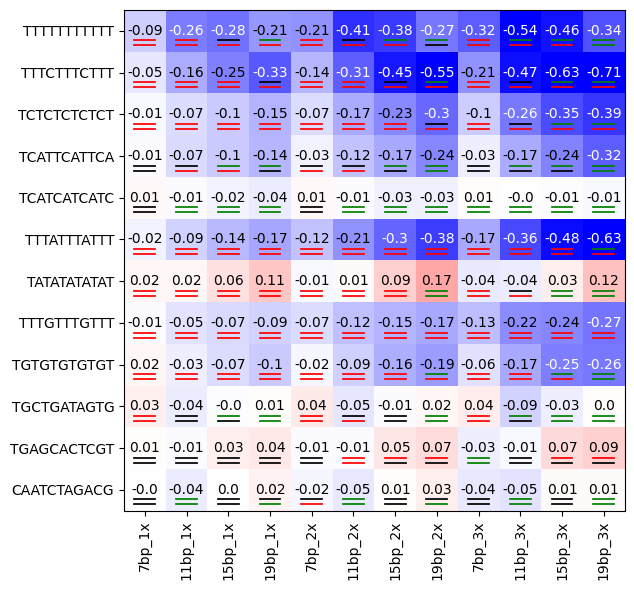

In [36]:
#Plot log coverage ratio differences between cell types (proximal)

f = plt.figure(figsize=(8, 6))

abs_max_val = 0.5#np.max(np.abs(prox_lcovrd))
neutral_margin = 0.05

plt.imshow(prox_lcovrd, aspect='equal', vmin=-abs_max_val, vmax=abs_max_val, cmap='bwr', zorder=-1)

for i in range(prox_lcovrd.shape[0]):
    for j in range(prox_lcovrd.shape[1]):
        annot_str = str(round(prox_lcovrd[i, j], 2))
        if np.abs(prox_lcovrd[i, j]) >= 0.5 * abs_max_val :
            plt.gca().text(j, i, annot_str, fontsize=10, color='white', ha="center", va="center", zorder=1)
        else :
            plt.gca().text(j, i, annot_str, fontsize=10, color='black', ha="center", va="center", zorder=1)
        
        if prox_lcovr[i, j, 0] < -neutral_margin :
            plt.plot([j-0.25, j+0.25], [i + 0.23, i + 0.23], color='green', linewidth=1.25, zorder=1)
        elif prox_lcovr[i, j, 0] > neutral_margin :
            plt.plot([j-0.25, j+0.25], [i + 0.23, i + 0.23], color='red', linewidth=1.25, zorder=1)
        else :
            plt.plot([j-0.25, j+0.25], [i + 0.23, i + 0.23], color='black', linewidth=1.25, zorder=1)
        
        if prox_lcovr[i, j, 1] < -neutral_margin :
            plt.plot([j-0.25, j+0.25], [i + 0.35, i + 0.35], color='green', linewidth=1.25, zorder=1)
        elif prox_lcovr[i, j, 1] > neutral_margin :
            plt.plot([j-0.25, j+0.25], [i + 0.35, i + 0.35], color='red', linewidth=1.25, zorder=1)
        else :
            plt.plot([j-0.25, j+0.25], [i + 0.35, i + 0.35], color='black', linewidth=1.25, zorder=1)

plt.xticks(np.arange(len(experiments), dtype='int32'), experiments, fontsize=10, rotation=90)
plt.yticks(np.arange(len(motifs), dtype='int32'), motifs, fontsize=10)

plt.tight_layout()

plt.savefig('MDH2_simulation_heatmap_prox.eps')

plt.show()


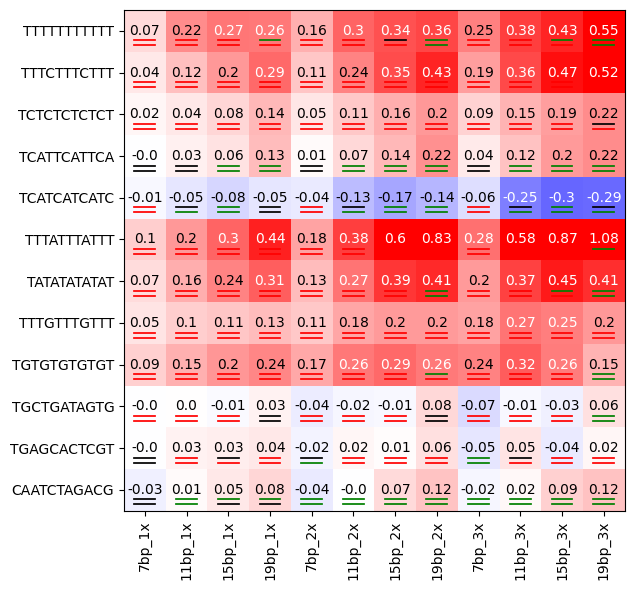

In [37]:
#Plot log coverage ratio differences between cell types (distal)

f = plt.figure(figsize=(8, 6))

abs_max_val = 0.5#np.max(np.abs(dist_lcovrd))
neutral_margin = 0.05

plt.imshow(dist_lcovrd, aspect='equal', vmin=-abs_max_val, vmax=abs_max_val, cmap='bwr')

for i in range(dist_lcovrd.shape[0]):
    for j in range(dist_lcovrd.shape[1]):
        annot_str = str(round(dist_lcovrd[i, j], 2))
        if np.abs(dist_lcovrd[i, j]) >= 0.5 * abs_max_val :
            plt.gca().text(j, i, annot_str, fontsize=10, color='white', ha="center", va="center", zorder=1)
        else :
            plt.gca().text(j, i, annot_str, fontsize=10, color='black', ha="center", va="center", zorder=1)
        
        #rect = patches.Rectangle((j-0.25 - 0.05, i + 0.23 - 0.08), 0.5 + 0.10, 0.12 + 0.16, edgecolor='black', facecolor='white', fill=True)
        #plt.gca().add_patch(rect)
        
        if dist_lcovr[i, j, 0] < -neutral_margin :
            plt.plot([j-0.25, j+0.25], [i + 0.23, i + 0.23], color='green', linewidth=1.25, zorder=1)
        elif dist_lcovr[i, j, 0] > neutral_margin :
            plt.plot([j-0.25, j+0.25], [i + 0.23, i + 0.23], color='red', linewidth=1.25, zorder=1)
        else :
            plt.plot([j-0.25, j+0.25], [i + 0.23, i + 0.23], color='black', linewidth=1.25, zorder=1)
        
        if dist_lcovr[i, j, 1] < -neutral_margin :
            plt.plot([j-0.25, j+0.25], [i + 0.35, i + 0.35], color='green', linewidth=1.25, zorder=1)
        elif dist_lcovr[i, j, 1] > neutral_margin :
            plt.plot([j-0.25, j+0.25], [i + 0.35, i + 0.35], color='red', linewidth=1.25, zorder=1)
        else :
            plt.plot([j-0.25, j+0.25], [i + 0.35, i + 0.35], color='black', linewidth=1.25, zorder=1)

plt.xticks(np.arange(len(experiments), dtype='int32'), experiments, fontsize=10, rotation=90)
plt.yticks(np.arange(len(motifs), dtype='int32'), motifs, fontsize=10)

plt.tight_layout()

plt.savefig('MDH2_simulation_heatmap_dist.eps')

plt.show()
